In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('custinfodata.xlsx')

In [3]:
df.head()

,Customer ID,monetary_value,Age
0,12346,169.36,42
1,12608,415.79,26
2,12745,723.85,56
3,12746,254.55,48
4,12747,5061.03,13


In [4]:
df.shape

(3953, 3)

In [5]:
X = df.iloc[:, [1,2]].values

In [6]:
X

array([[ 169.36,   42.  ],
       [ 415.79,   26.  ],
       [ 723.85,   56.  ],
       ...,
       [ 377.  ,   23.  ],
       [1246.43,   22.  ],
       [2295.71,   24.  ]])

In [7]:
from sklearn.cluster import KMeans 
wcss = []

In [8]:
for i in range(1,11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

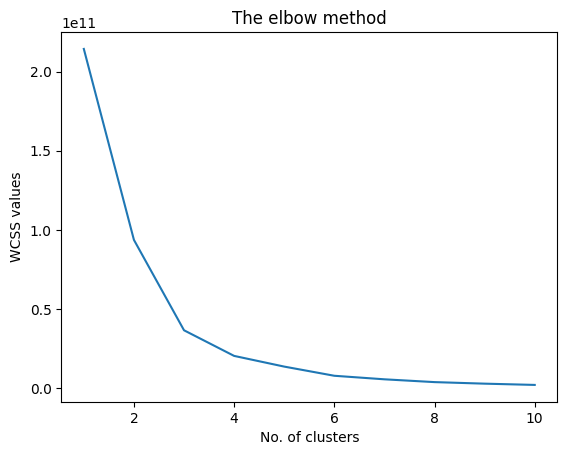

In [9]:
plt.plot(range(1,11), wcss)
plt.title('The elbow method')
plt.xlabel('No. of clusters')
plt.ylabel('WCSS values')
plt.show()

In [10]:
kmeansmodel = KMeans(n_clusters = 5, init ='k-means++', random_state=0) 

In [11]:
y_kmeans = kmeansmodel.fit_predict(X)

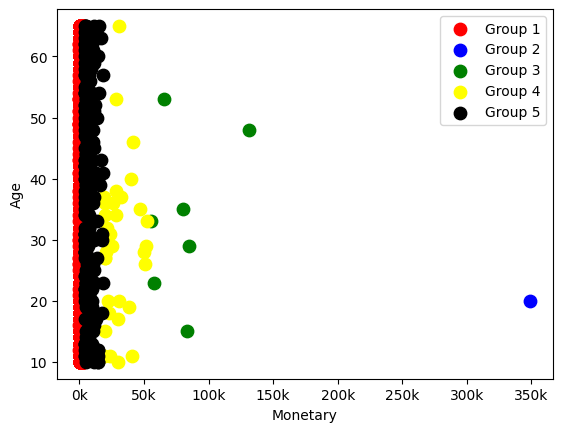

In [12]:
from matplotlib.ticker import FuncFormatter
plt.scatter(X[y_kmeans == 0,0], X[y_kmeans == 0,1], s = 80, c ="red", label = 'Group 1')
plt.scatter(X[y_kmeans == 1,0], X[y_kmeans == 1,1], s = 80, c ="blue", label = 'Group 2')
plt.scatter(X[y_kmeans == 2,0], X[y_kmeans == 2,1], s = 80, c ="green", label = 'Group 3')
plt.scatter(X[y_kmeans == 3,0], X[y_kmeans == 3,1], s = 80, c ="yellow", label = 'Group 4')
plt.scatter(X[y_kmeans == 4,0], X[y_kmeans == 4,1], s = 80, c ="black", label = 'Group 5')
def format_func(value, tick_number):
    return f'{int(value/1000)}k'
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_func))
plt.title('')
plt.legend()
plt.ylabel('Age')
plt.xlabel('Monetary')
plt.show()

**Age vs Spendings**

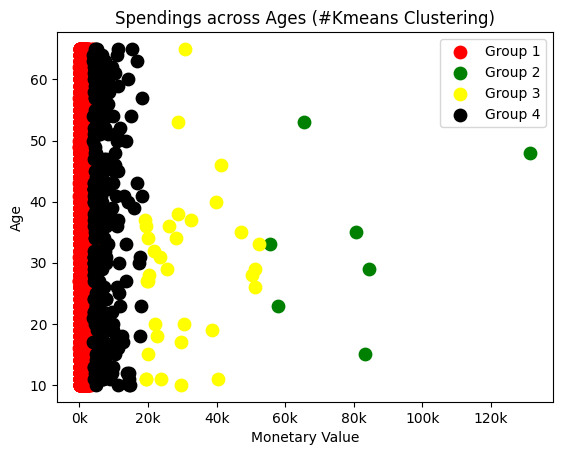

In [17]:
from matplotlib.ticker import FuncFormatter
plt.scatter(X[y_kmeans == 0,0], X[y_kmeans == 0,1], s = 80, c ="red", label = 'Group 1')
plt.scatter(X[y_kmeans == 2,0], X[y_kmeans == 2,1], s = 80, c ="green", label = 'Group 2')
plt.scatter(X[y_kmeans == 3,0], X[y_kmeans == 3,1], s = 80, c ="yellow", label = 'Group 3')
plt.scatter(X[y_kmeans == 4,0], X[y_kmeans == 4,1], s = 80, c ="black", label = 'Group 4')
def format_func(value, tick_number):
    return f'{int(value/1000)}k'
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_func))
plt.title('')
plt.legend()
plt.ylabel('Age')
plt.xlabel('Monetary Value')
plt.title('Spendings across Ages (#Kmeans Clustering)')
plt.savefig('C:/Users/USER/Desktop/Analysis/spendingsvages.jpg')
plt.show()